In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# File paths

In [2]:
apms_file = "apms-2014-ch-03-tabs.xls"
csew_file = "csew_dataset.xlsx"

output_folder = "cross_dataset_outputs"
os.makedirs(output_folder, exist_ok=True)

# Load APMS Table 3.1
# Table 3.1 contains treatment received for mental/emotional problem

In [3]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'apms-2014-ch-03-tabs.xls', 'cross_dataset_outputs', 'csew_dataset.xlsx', 'Untitled.ipynb']


In [4]:
apms_raw = pd.read_excel(
    apms_file,
    sheet_name="3.1",
    header=None
)

print("APMS Table 3.1 Preview:")
print(apms_raw.head(15))

APMS Table 3.1 Preview:
                                                    0  \
0   Table 3.1  Treatment currently received for a ...   
1                                          All adults   
2                                                 NaN   
3                                  Type of treatmenta   
4                                                 NaN   
5                                                 Men   
6                                        No treatment   
7                                     Medication only   
8                         Counselling or therapy only   
9                     Both medication and counselling   
10                                     Any medication   
11                         Any counselling or therapy   
12                                     Any treatment    
13                                                NaN   
14                                              Women   

                          1          2          3          4   

#  Extract APMS gender-wise mental health treatment values

In [5]:

apms_records = []

gender_sections = {
    "Men": (6, 12),
    "Women": (15, 21),
    "All adults": (24, 30)
}

for gender, (start, end) in gender_sections.items():
    temp = apms_raw.iloc[start:end+1, [0, 5]].copy()
    temp.columns = ["Indicator", "APMS_Rate"]
    temp["Gender"] = gender
    apms_records.append(temp)

apms_clean = pd.concat(apms_records, ignore_index=True)

apms_clean["APMS_Rate"] = pd.to_numeric(apms_clean["APMS_Rate"], errors="coerce")

print("\nCleaned APMS Data:")
print(apms_clean)


Cleaned APMS Data:
                          Indicator  APMS_Rate      Gender
0                      No treatment  90.442715         Men
1                   Medication only   7.045228         Men
2       Counselling or therapy only   1.059073         Men
3   Both medication and counselling   1.452984         Men
4                    Any medication   8.498212         Men
5        Any counselling or therapy   2.512057         Men
6                    Any treatment    9.557285         Men
7                      No treatment  83.531054       Women
8                   Medication only  13.038191       Women
9       Counselling or therapy only   1.938828       Women
10  Both medication and counselling   1.491927       Women
11                   Any medication  14.530119       Women
12       Any counselling or therapy   3.431203       Women
13                   Any treatment   16.468946       Women
14                     No treatment  86.907478  All adults
15                  Medication only 

# Load CSEW Table S44
# Table S44 contains harassment prevalence by sex

In [6]:
csew_raw = pd.read_excel(
    csew_file,
    sheet_name="Table S44",
    header=None
)

print("\nCSEW Table S44 Preview:")
print(csew_raw.head(12))


CSEW Table S44 Preview:
                                                  0   \
0  Table S44: Prevalence of harassment experience...   
1          England and Wales, year ending March 2024   
2  This worksheet contains one table. Some cells ...   
3                            Link to Notes worksheet   
4                          Link to Table of contents   
5  Source: Crime Survey for England and Wales fro...   
6                            Personal characteristic   
7                        All people aged 16 and over   
8                                                Sex   
9                                                Sex   

                                   1   \
0                                 NaN   
1                                 NaN   
2                                 NaN   
3                                 NaN   
4                                 NaN   
5                                 NaN   
6  Personal characteristics breakdown   
7                          ALL

# Extract CSEW gender-wise harassment values

In [7]:
csew_clean = csew_raw.iloc[8:10, [1, 8]].copy()
csew_clean.columns = ["Gender", "CSEW_Rate"]

csew_clean["CSEW_Rate"] = pd.to_numeric(csew_clean["CSEW_Rate"], errors="coerce")

print("\nCleaned CSEW Data:")
print(csew_clean)


Cleaned CSEW Data:
  Gender  CSEW_Rate
8    Men   6.642237
9  Women  11.192277


# Select one APMS indicator for comparison
# Here we use "Any treatment"

In [8]:
print(apms_clean["Indicator"].unique())

['No treatment' 'Medication only' 'Counselling or therapy only'
 'Both medication and counselling' 'Any medication'
 'Any counselling or therapy' 'Any treatment ']


In [9]:
apms_clean["Indicator"] = (
    apms_clean["Indicator"]
    .astype(str)
    .str.strip()
    .str.lower()
)

In [10]:
print(apms_clean["Indicator"].unique())

['no treatment' 'medication only' 'counselling or therapy only'
 'both medication and counselling' 'any medication'
 'any counselling or therapy' 'any treatment']


In [11]:
# Extract any treatment rows
apms_any_treatment = apms_clean[
    apms_clean["Indicator"].str.contains(
        "any treatment",
        case=False,
        na=False
    )
].copy()

# Keep only men and women
apms_any_treatment = apms_any_treatment[
    apms_any_treatment["Gender"].isin(["Men", "Women"])
]

print(apms_any_treatment)

        Indicator  APMS_Rate Gender
6   any treatment   9.557285    Men
13  any treatment  16.468946  Women


# Merge APMS and CSEW on Gender

In [12]:
comparison = pd.merge(
    apms_any_treatment[["Gender", "APMS_Rate"]],
    csew_clean,
    on="Gender",
    how="inner"
)

comparison["Difference"] = comparison["APMS_Rate"] - comparison["CSEW_Rate"]
comparison["Abs_Difference"] = comparison["Difference"].abs()

comparison["Agreement_Status"] = np.where(
    comparison["Abs_Difference"] <= 5,
    "Agreement",
    "Conflict"
)

print("\nFinal Cross Dataset Comparison:")
print(comparison)


Final Cross Dataset Comparison:
  Gender  APMS_Rate  CSEW_Rate  Difference  Abs_Difference Agreement_Status
0    Men   9.557285   6.642237    2.915048        2.915048        Agreement
1  Women  16.468946  11.192277    5.276669        5.276669         Conflict


# Save comparison report

In [13]:
comparison.to_csv(
    f"{output_folder}/APMS_CSEW_gender_comparison.csv",
    index=False
)

apms_clean.to_csv(
    f"{output_folder}/cleaned_APMS_table_3_1.csv",
    index=False
)

csew_clean.to_csv(
    f"{output_folder}/cleaned_CSEW_table_S44.csv",
    index=False
)

print("\nCSV files saved successfully.")


CSV files saved successfully.


# Visualization: APMS vs CSEW Gender Comparison

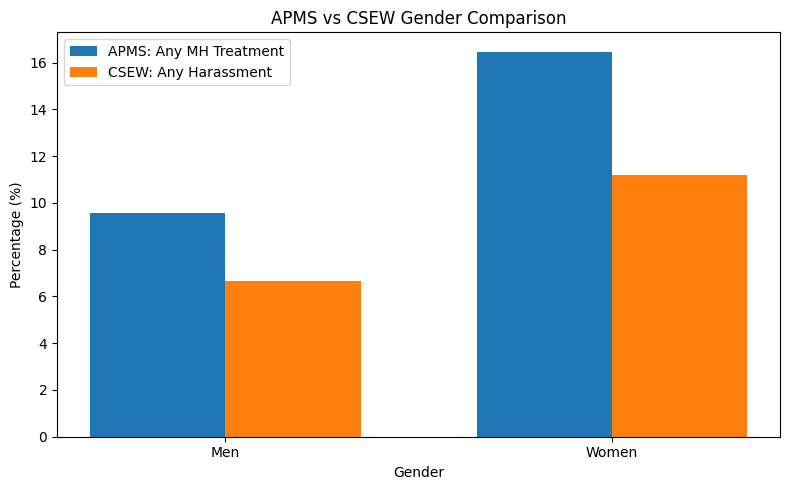

In [14]:
x = np.arange(len(comparison["Gender"]))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width/2,
    comparison["APMS_Rate"],
    width,
    label="APMS: Any MH Treatment"
)

plt.bar(
    x + width/2,
    comparison["CSEW_Rate"],
    width,
    label="CSEW: Any Harassment"
)

plt.title("APMS vs CSEW Gender Comparison")
plt.xlabel("Gender")
plt.ylabel("Percentage (%)")
plt.xticks(x, comparison["Gender"])
plt.legend()
plt.tight_layout()

plt.savefig(f"{output_folder}/APMS_CSEW_gender_comparison_chart.png")
plt.show()

# Agreement / Conflict Chart

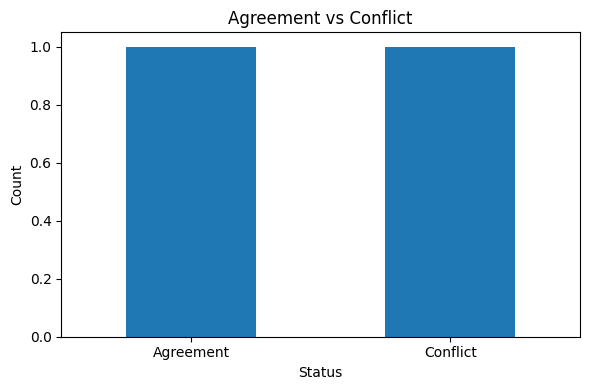

In [15]:
status_count = comparison["Agreement_Status"].value_counts()

plt.figure(figsize=(6, 4))
status_count.plot(kind="bar")

plt.title("Agreement vs Conflict")
plt.xlabel("Status")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(f"{output_folder}/agreement_conflict_chart.png")
plt.show()

# Generate interpretation notes

In [16]:
notes = []

for _, row in comparison.iterrows():
    note = (
        f"For {row['Gender']}, APMS shows {row['APMS_Rate']:.2f}% "
        f"receiving any mental health treatment, while CSEW shows "
        f"{row['CSEW_Rate']:.2f}% experiencing any harassment. "
        f"This is classified as {row['Agreement_Status']}."
    )
    notes.append(note)

with open(f"{output_folder}/interpretation_notes.txt", "w", encoding="utf-8") as f:
    for note in notes:
        f.write(note + "\n")

print("\nInterpretation notes created successfully.")


Interpretation notes created successfully.


# Final Excel Report

In [17]:
with pd.ExcelWriter(f"{output_folder}/APMS_CSEW_Final_Report.xlsx") as writer:
    apms_clean.to_excel(writer, sheet_name="APMS Cleaned", index=False)
    csew_clean.to_excel(writer, sheet_name="CSEW Cleaned", index=False)
    comparison.to_excel(writer, sheet_name="Comparison", index=False)

print("\nFinal Excel report created successfully.")


Final Excel report created successfully.
